# EDA & 결과 분석 — Amazon 상품 다중 라벨 분류

이 노트북은 `pipeline.ipynb`(BERT + Weak Supervision + Self-Training)로 학습/제출하기 **전후의 데이터와 결과를 정량적으로 분석**합니다.
테스트셋의 정답(ground truth)은 공개되지 않으므로, 여기서는 **(1) 입력 데이터, (2) 약한 라벨(silver label), (3) 최종 제출 결과**를
직접 측정·시각화하여 모델 설계 선택과 한계를 근거 있게 설명합니다.

**목차**
1. 데이터셋 개요
2. 문서 길이 분석 → `max_len` 선택 검증
3. 클래스 계층(taxonomy) 구조 분석
4. 키워드 리소스 분석
5. 약한 감독(silver label) 커버리지
6. 최종 제출 결과 분석
7. 요약 & 한계

## 0. 환경 & 데이터 로딩
로더는 `pipeline.ipynb`와 동일한 규칙을 사용해 재현성을 보장합니다.

In [1]:
import re
from pathlib import Path
from collections import defaultdict, Counter, deque
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

ROOT = Path("Amazon_products")
FIG = Path("figures"); FIG.mkdir(exist_ok=True)

def load_classes(path):
    id2name, name2id = {}, {}
    with open(path, encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) >= 2:
                cid, cname = int(parts[0]), parts[1]
                id2name[cid] = cname; name2id[cname] = cid
    return id2name, name2id

def load_hierarchy(path):
    parents = defaultdict(list)
    with open(path, encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) >= 2:
                p, c = int(parts[0]), int(parts[1])
                parents[c].append(p)
    return parents

def load_keywords(path, name2id):
    ck = {}
    with open(path, encoding="utf-8") as f:
        for line in f:
            if ":" in line:
                cname, kw = line.strip().split(":", 1)
                kws = [k.strip() for k in kw.split(",")]
                if cname in name2id:
                    ck[name2id[cname]] = kws
    return ck

def load_corpus(path):
    data = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("\t", 1)
            if len(parts) == 2:
                data.append((int(parts[0]), parts[1]))
    data.sort(key=lambda x: x[0])
    return data

id2name, name2id = load_classes(ROOT / "classes.txt")
parents_map = load_hierarchy(ROOT / "class_hierarchy.txt")
class_keywords = load_keywords(ROOT / "class_related_keywords.txt", name2id)
train = load_corpus(ROOT / "train" / "train_corpus.txt")
test = load_corpus(ROOT / "test" / "test_corpus.txt")
num_classes = len(id2name)
print(f"classes={num_classes}  train={len(train)}  test={len(test)}  "
      f"hierarchy_edges={sum(len(v) for v in parents_map.values())}  "
      f"keyword_entries={len(class_keywords)}")

classes=531  train=29487  test=19658  hierarchy_edges=568  keyword_entries=531


## 1. 데이터셋 개요
학습/평가 규모와 라벨 공간(클래스 수)을 정리합니다.

In [2]:
overview = pd.DataFrame({
    "metric": ["train documents", "test documents", "num classes",
               "hierarchy edges", "keyword entries"],
    "value":  [len(train), len(test), num_classes,
               sum(len(v) for v in parents_map.values()), len(class_keywords)],
})
print(overview.to_string(index=False))
print("\n예시 문서:", train[0][1][:160], "...")

         metric  value
train documents  29487
 test documents  19658
    num classes    531
hierarchy edges    568
keyword entries    531

예시 문서: omron hem 790it automatic blood pressure monitor with advanced omron health management software so far this machine has worked well and is very simple to use .  ...


## 2. 문서 길이 분석 → `max_len` 선택 검증
BERT 입력 길이(`max_len`)는 정보 손실과 연산량의 트레이드오프입니다.
파이프라인은 `max_len=128`을 사용하는데, 실제 문서 길이 분포로 이 선택의 영향을 정량화합니다.

         train     test
count  29487.0  19658.0
mean      98.4     98.5
std       81.8     80.6
min       25.0     25.0
25%       46.0     47.0
50%       74.0     75.0
75%      121.0    121.0
max     1708.0   1340.0



128 단어를 초과하는 학습 문서 비율: 22.4%  → max_len=128 은 약 1/5 문서의 뒷부분을 잘라냅니다.


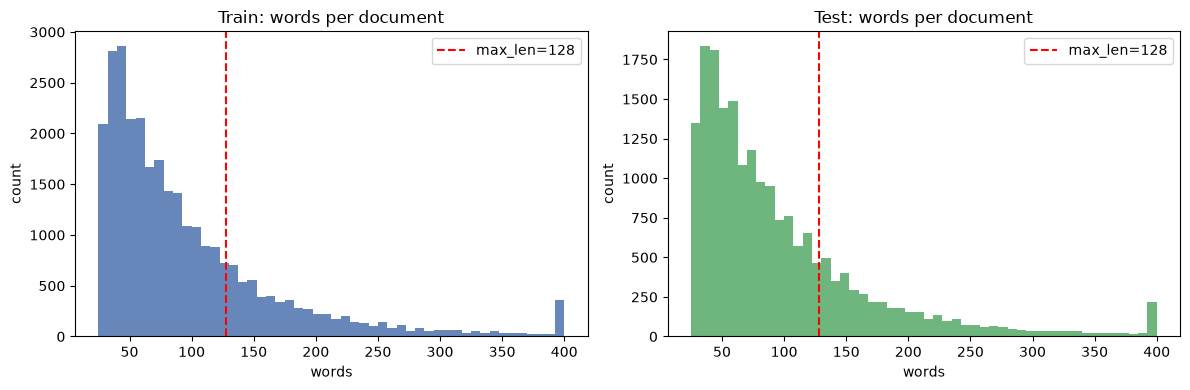

In [3]:
def word_len(corpus): return np.array([len(t.split()) for _, t in corpus])
tr_w, te_w = word_len(train), word_len(test)

desc = pd.DataFrame({"train": pd.Series(tr_w).describe(),
                     "test":  pd.Series(te_w).describe()}).round(1)
print(desc.to_string())
pct_over = (tr_w > 128).mean() * 100
print(f"\n128 단어를 초과하는 학습 문서 비율: {pct_over:.1f}%  "
      f"→ max_len=128 은 약 1/5 문서의 뒷부분을 잘라냅니다.")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, w, t, c in [(ax[0], tr_w, "Train", "#4C72B0"), (ax[1], te_w, "Test", "#55A868")]:
    a.hist(np.clip(w, 0, 400), bins=50, color=c, alpha=0.85)
    a.axvline(128, color="red", ls="--", label="max_len=128")
    a.set_title(f"{t}: words per document"); a.set_xlabel("words"); a.set_ylabel("count"); a.legend()
plt.tight_layout(); plt.savefig(FIG / "01_text_length.png", dpi=110); plt.show()

> **인사이트.** 중앙값은 ~74단어로 `max_len=128` 안에 들어오지만, **22.4%의 문서가 128단어를 초과**합니다.
> 즉 긴 리뷰의 후반 정보는 학습에 반영되지 않습니다. → 개선 후보: `max_len` 상향, 또는 sliding-window/longformer 계열.

## 3. 클래스 계층(taxonomy) 구조 분석
`class_hierarchy.txt`의 부모-자식 관계로 분류 체계의 구조를 분석합니다.
약한 라벨을 부모로 전파(label propagation)하는 근거가 되는 부분입니다.

루트 노드: 6개 (최상위 카테고리)
리프 노드: 462개
최대 깊이: 2 (0부터 시작 → 3단계 계층)
다중 부모를 가진 클래스: 25개 (최대 7개 부모) → 트리가 아니라 DAG
부모당 자식 수: 평균 8.2, 최대 25
루트 카테고리: ['grocery_gourmet_food', 'toys_games', 'beauty', 'health_personal_care', 'baby_products', 'pet_supplies']


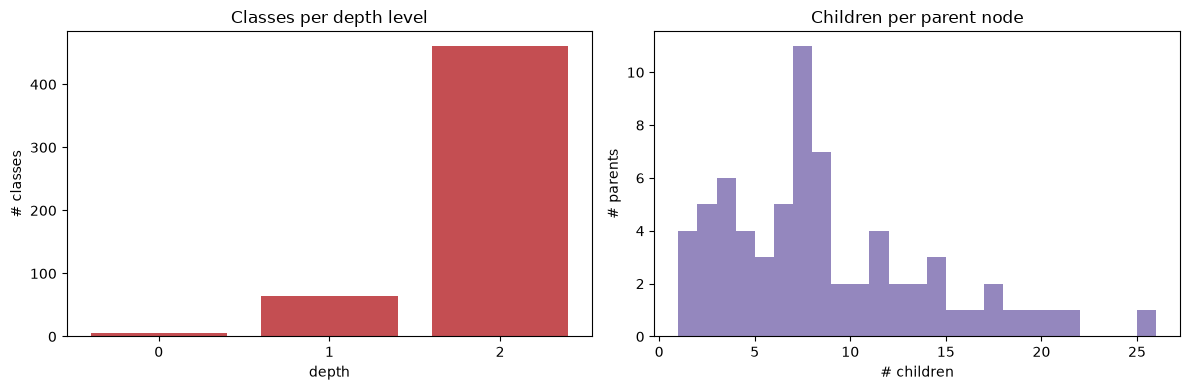

In [4]:
children = defaultdict(list)
for c, ps in parents_map.items():
    for p in ps: children[p].append(c)
roots = [n for n in id2name if n not in parents_map or len(parents_map[n]) == 0]
leaves = [n for n in id2name if n not in children]

depth = {r: 0 for r in roots}
dq = deque((r, 0) for r in roots)
while dq:
    n, d = dq.popleft()
    for c in children.get(n, []):
        if c not in depth or d + 1 < depth[c]:
            depth[c] = d + 1; dq.append((c, d + 1))

nchild = [len(children[p]) for p in children]
print(f"루트 노드: {len(roots)}개 (최상위 카테고리)")
print(f"리프 노드: {len(leaves)}개")
print(f"최대 깊이: {max(depth.values())} (0부터 시작 → 3단계 계층)")
print(f"다중 부모를 가진 클래스: {sum(1 for v in parents_map.values() if len(v) > 1)}개 "
      f"(최대 {max(len(v) for v in parents_map.values())}개 부모) → 트리가 아니라 DAG")
print(f"부모당 자식 수: 평균 {np.mean(nchild):.1f}, 최대 {max(nchild)}")
print("루트 카테고리:", [id2name[r] for r in roots])

depth_counts = Counter(depth.values())
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ds = sorted(depth_counts)
ax[0].bar([str(d) for d in ds], [depth_counts[d] for d in ds], color="#C44E52")
ax[0].set_title("Classes per depth level"); ax[0].set_xlabel("depth"); ax[0].set_ylabel("# classes")
ax[1].hist(nchild, bins=range(1, max(nchild) + 2), color="#8172B3", alpha=0.85)
ax[1].set_title("Children per parent node"); ax[1].set_xlabel("# children"); ax[1].set_ylabel("# parents")
plt.tight_layout(); plt.savefig(FIG / "02_taxonomy.png", dpi=110); plt.show()

> **인사이트.** 얕고(최대 깊이 2) 넓은 구조이며 **다중 부모(DAG)** 가 존재합니다.
> 따라서 단순 트리 가정이 아니라 BFS로 모든 조상을 전파해야 하며, 이는 파이프라인의 라벨 전파 로직과 일치합니다.

## 4. 키워드 리소스 분석
약한 감독에 쓰이는 클래스별 키워드 사전의 분포입니다.

In [5]:
kw_counts = [len(v) for v in class_keywords.values()]
print(f"클래스당 키워드 수: 평균 {np.mean(kw_counts):.1f}, 최소 {min(kw_counts)}, 최대 {max(kw_counts)}")
print("예시 — grocery_gourmet_food:", class_keywords[name2id['grocery_gourmet_food']])

클래스당 키워드 수: 평균 9.9, 최소 1, 최대 10
예시 — grocery_gourmet_food: ['snacks', 'condiments', 'beverages', 'specialty_foods', 'spices', 'cooking_oils', 'baking_ingredients', 'gourmet_chocolates', 'artisanal_cheeses', 'organic_foods']


## 5. 약한 감독(silver label) 커버리지
`pipeline.ipynb`의 정규식 키워드 매칭 + 계층 전파를 **그대로 재현**하여,
약한 라벨이 데이터를 얼마나 덮는지(coverage)를 측정합니다. (결과가 파이프라인 로그의 19,500/9,987과 일치해야 함)

라벨 부여됨(Seed): 19500    라벨 없음(Unlabeled): 9987
커버리지: 66.1%   문서당 평균 라벨 수: 6.77
한 번이라도 silver label을 받은 클래스: 277 / 531 (→ 254개 클래스는 약한 라벨 0개)


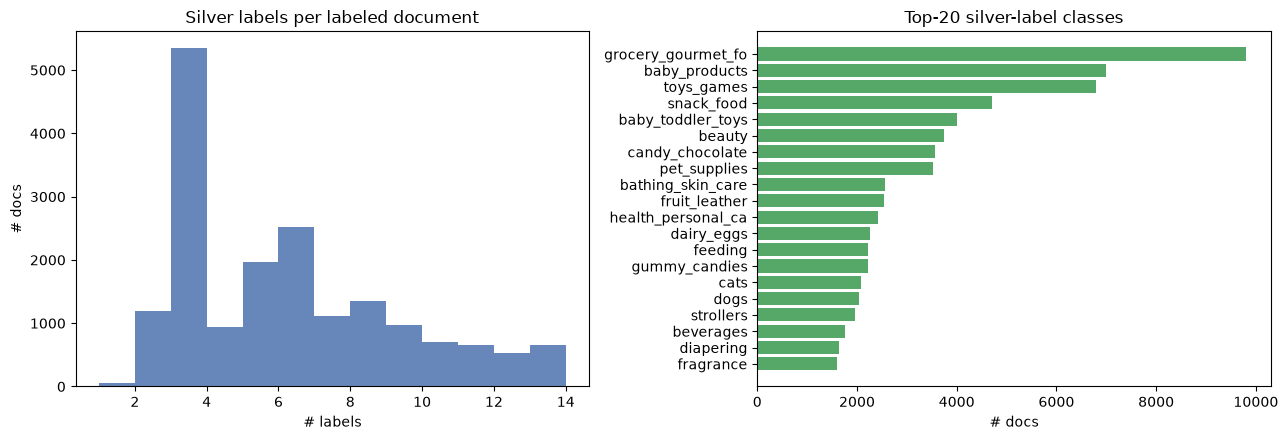

In [6]:
compiled = {cid: re.compile(r"\b(" + "|".join(map(re.escape, kws)) + r")\b")
            for cid, kws in class_keywords.items()}

labels_per_sample, class_freq, n_labeled = [], Counter(), 0
for did, text in train:
    tl = text.lower()
    matched = {cid for cid, pat in compiled.items() if pat.search(tl)}
    if matched:
        queue, visited = list(matched), set(matched)
        while queue:
            cur = queue.pop(0)
            for p in parents_map.get(cur, []):
                if p not in visited: visited.add(p); queue.append(p)
        n_labeled += 1; labels_per_sample.append(len(visited))
        for c in visited: class_freq[c] += 1

print(f"라벨 부여됨(Seed): {n_labeled}    라벨 없음(Unlabeled): {len(train)-n_labeled}")
print(f"커버리지: {n_labeled/len(train)*100:.1f}%   문서당 평균 라벨 수: {np.mean(labels_per_sample):.2f}")
print(f"한 번이라도 silver label을 받은 클래스: {len(class_freq)} / {num_classes} "
      f"(→ {num_classes-len(class_freq)}개 클래스는 약한 라벨 0개)")

top = class_freq.most_common(20)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].hist(labels_per_sample, bins=range(1, 15), color="#4C72B0", alpha=0.85)
ax[0].set_title("Silver labels per labeled document"); ax[0].set_xlabel("# labels"); ax[0].set_ylabel("# docs")
ax[1].barh([id2name[c][:18] for c, _ in top][::-1], [v for _, v in top][::-1], color="#55A868")
ax[1].set_title("Top-20 silver-label classes"); ax[1].set_xlabel("# docs")
plt.tight_layout(); plt.savefig(FIG / "03_silver_labels.png", dpi=110); plt.show()

> **인사이트.** 약한 라벨은 학습셋의 **66.1%만** 덮고, **531개 중 277개 클래스에만** 신호를 줍니다.
> 나머지 절반 가까운 클래스는 약한 라벨이 0개라, self-training이 이를 메우지 못하면 사실상 학습되지 않습니다.
> 이것이 self-training(unlabeled 활용)을 도입한 직접적 동기입니다.

## 6. 최종 제출 결과 분석
`submission_finals.csv`(top-3 예측)의 라벨 분포를 분석해, 모델 출력의 편향을 확인합니다.

제출 행: 19658   문서당 라벨 수(평균): 3.00 (top-3 전략)
실제 예측에 사용된 클래스: 108 / 531 (→ 423개 클래스는 한 번도 예측되지 않음)


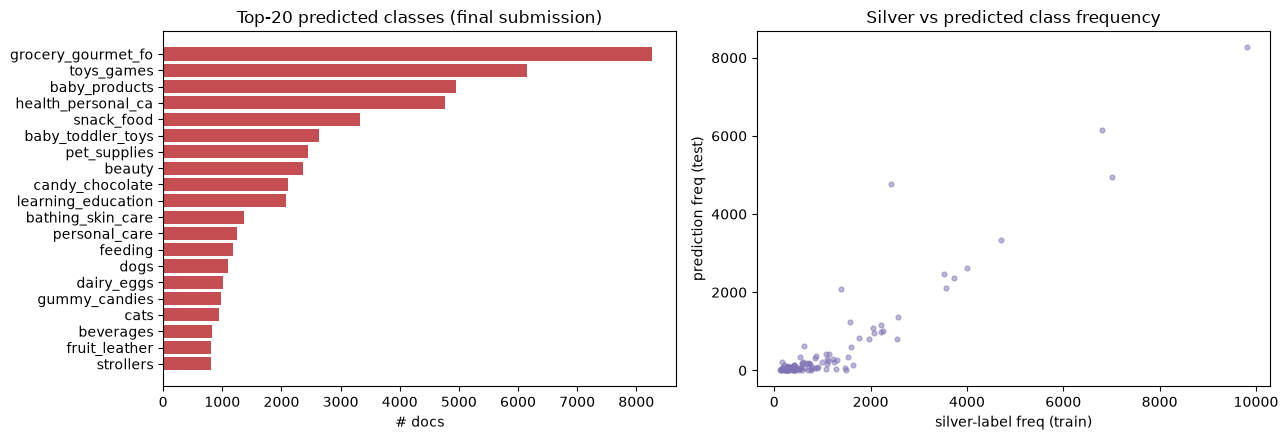

In [7]:
sub = pd.read_csv("submission_finals.csv")
pred_counts, lpp = Counter(), []
for lab in sub["label"]:
    ids = [int(x) for x in str(lab).split(",") if x.strip()]
    lpp.append(len(ids))
    for i in ids: pred_counts[i] += 1

print(f"제출 행: {len(sub)}   문서당 라벨 수(평균): {np.mean(lpp):.2f} (top-3 전략)")
print(f"실제 예측에 사용된 클래스: {len(pred_counts)} / {num_classes} "
      f"(→ {num_classes-len(pred_counts)}개 클래스는 한 번도 예측되지 않음)")

top = pred_counts.most_common(20)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].barh([id2name.get(c, str(c))[:18] for c, _ in top][::-1], [v for _, v in top][::-1], color="#C44E52")
ax[0].set_title("Top-20 predicted classes (final submission)"); ax[0].set_xlabel("# docs")
ax[1].scatter([class_freq.get(c, 0) for c in pred_counts],
              [pred_counts[c] for c in pred_counts], s=12, alpha=0.5, color="#8172B3")
ax[1].set_xlabel("silver-label freq (train)"); ax[1].set_ylabel("prediction freq (test)")
ax[1].set_title("Silver vs predicted class frequency")
plt.tight_layout(); plt.savefig(FIG / "04_submission.png", dpi=110); plt.show()

> **인사이트.** 최종 예측은 **531개 중 108개 클래스에만** 집중됩니다(423개는 미사용).
> 우측 산점도처럼 **예측 빈도가 silver-label 빈도와 강하게 양의 상관**을 보이는데,
> 이는 모델이 약한 감독 신호가 강한 다수(head) 클래스로 쏠리고 희소(tail) 클래스를 놓친다는 뜻입니다(클래스 불균형 → long-tail).

## 7. 요약 & 한계

**확인된 사실 (정량적 근거)**

| 항목 | 수치 |
|---|---|
| 학습 / 테스트 문서 | 29,487 / 19,658 |
| 클래스 수 (계층, DAG) | 531 (루트 6, 최대 깊이 2, 다중부모 25) |
| 128단어 초과 문서 | 22.4% (max_len=128로 truncate) |
| 약한 라벨 커버리지 | 66.1% (라벨 19,500 / 미라벨 9,987) |
| 약한 라벨이 닿은 클래스 | 277 / 531 |
| 최종 예측에 쓰인 클래스 | 108 / 531 |

**한계 & 개선 방향**
1. **평가지표 부재의 근본 원인** — 테스트 정답이 비공개이고 학습 모델 체크포인트도 저장되지 않아, 사후 정량 평가가 불가능.
   → `evaluation.ipynb`에서 약한 라벨을 train/val로 분리해 **재현 가능한 F1 측정 프로토콜**을 제공.
2. **Long-tail 미해결** — 클래스의 절반이 약한 라벨 0개, 예측은 108개 클래스에 집중.
   → 키워드 사전 보강, 클래스 가중 손실, 임계값/Top-k 보정.
3. **입력 truncation** — 22%의 문서가 잘림. → `max_len` 상향 또는 long-context 인코더.
4. **모델 영속화 부재** — `torch.save`로 체크포인트 저장 시 재평가/재현 용이.